In [ ]:
import pandas as pd
import deeplay
import importlib
import data.MultiAssetDataset_v3
importlib.reload(data.MultiAssetDataset_v3)
from data.MultiAssetDataset_v3 import MultiAssetSequencedDataset
from torch.utils.data import DataLoader

df = pd.read_csv("data/OMXS22_model_features_raw.csv", index_col = "Date", parse_dates = True)
# Take out kinnevik and nibe

tickers = df["Ticker"].unique().tolist()
print(df.head())
features = ["Close"]
target_col = "Close"
window   = 100
window_step_length = 6
horizon  = [i for i in range(1, 11)]


train_stop = pd.Timestamp("2016-01-01")
val_stop = pd.Timestamp("2022-11-23")

df_train = df[df.index < train_stop].copy()

df_val   = df[(df.index >= train_stop) & (df.index < val_stop)].copy()
df_test  = df[df.index >= val_stop].copy()
df_val_test = df[df.index >= train_stop].copy()


ds_train = MultiAssetSequencedDataset(df_train, tickers, features, target_col, False, window, window_step_length=50, horizon=horizon, num_permutations=75)
ds_train.create()
ds_val   = MultiAssetSequencedDataset(df_val,   tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_val.create()
ds_test  = MultiAssetSequencedDataset(df_test,  tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_test.create()
ds_val_test = MultiAssetSequencedDataset(df_val_test,  tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_val_test.create()


train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
val_loader   = DataLoader(ds_val,   batch_size=32)
test_loader  = DataLoader(ds_test,  batch_size=32)

print(f"Train set length: {len(ds_train)}")
print(f"Train set input shape: {ds_train[0][0].shape}")
print(f"Train set target shape: {ds_train[0][1].shape}")
print(f"Val set length: {len(ds_val)}")
print(f"Dataset length: {len(ds_train) + len(ds_val) + len(ds_test)}")

print(f"Test set number of days: {len(df_test.index.unique())}")
print(f"Test set number of sequences: {len(ds_test)}")

print(f"first day of test set trading: {ds_test.target_dates[0]}")


               Ticker       Close    Return  LogReturn      Volume  SMA20  \
Date                                                                        
2000-01-04  ASSA-B.ST   23.572845 -0.050000  -0.051293   1681974.0    0.0   
2000-01-04  ATCO-A.ST    3.945862 -0.044747  -0.045779  29996128.0    0.0   
2000-01-04  ATCO-B.ST    3.067595 -0.047809  -0.048989   3956152.0    0.0   
2000-01-04     AZN.ST  279.147308 -0.031655  -0.032166   2738295.0    0.0   
2000-01-04  ELUX-B.ST   31.041374 -0.013889  -0.013986   3385217.0    0.0   

                 EMA20      RSI14  ReturnVola20  OMXS30_ret  USD_SEK_ret  \
Date                                                                       
2000-01-04   26.375874  74.255529      0.027978   -0.034201    -0.007497   
2000-01-04    3.990954  48.970023      0.024745   -0.034201    -0.007497   
2000-01-04    3.121727  52.314221      0.029787   -0.034201    -0.007497   
2000-01-04  278.932230  30.501235      0.017450   -0.034201    -0.007497   
2000

In [86]:
import torch
import torch.nn as nn
import torch.optim as optim
from multi_asset_models.MultiAssetLSTM import MultiAssetLSTM
from train.Trainer import Trainer

model = MultiAssetLSTM(
    n_assets=len(tickers),
    n_features=len(features),
    hidden_size=132,
    num_layers=2,
    dropout=0.3,
    horizon=horizon
)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs   = 50
patience     = num_epochs
save_path    = "best_multiasset_lstm.pt"

trainer = Trainer(model, optimizer, criterion)
history = trainer.fit(
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = num_epochs,
    patience     = patience,
    save_path    = save_path
)

model.load_state_dict(torch.load(save_path))

Epoch 1/50 - train_loss: 0.7688, val_loss: 0.7042
Epoch 2/50 - train_loss: 0.6108, val_loss: 0.6921
Epoch 3/50 - train_loss: 0.5945, val_loss: 0.6704
Epoch 4/50 - train_loss: 0.5852, val_loss: 0.6393
Epoch 5/50 - train_loss: 0.5785, val_loss: 0.6558
Epoch 6/50 - train_loss: 0.5738, val_loss: 0.6398
Epoch 7/50 - train_loss: 0.5681, val_loss: 0.6412
Epoch 8/50 - train_loss: 0.5669, val_loss: 0.6504
Epoch 9/50 - train_loss: 0.5628, val_loss: 0.6395
Epoch 10/50 - train_loss: 0.5609, val_loss: 0.6285
Epoch 11/50 - train_loss: 0.5573, val_loss: 0.6510
Epoch 12/50 - train_loss: 0.5533, val_loss: 0.6317
Epoch 13/50 - train_loss: 0.5504, val_loss: 0.6414
Epoch 14/50 - train_loss: 0.5458, val_loss: 0.6550
Epoch 15/50 - train_loss: 0.5378, val_loss: 0.6503
Epoch 16/50 - train_loss: 0.5300, val_loss: 0.6424
Epoch 17/50 - train_loss: 0.5247, val_loss: 0.6500
Epoch 18/50 - train_loss: 0.5206, val_loss: 0.6439
Epoch 19/50 - train_loss: 0.5158, val_loss: 0.6493
Epoch 20/50 - train_loss: 0.5100, val_lo

<All keys matched successfully>

Naive MAE: 1.8210


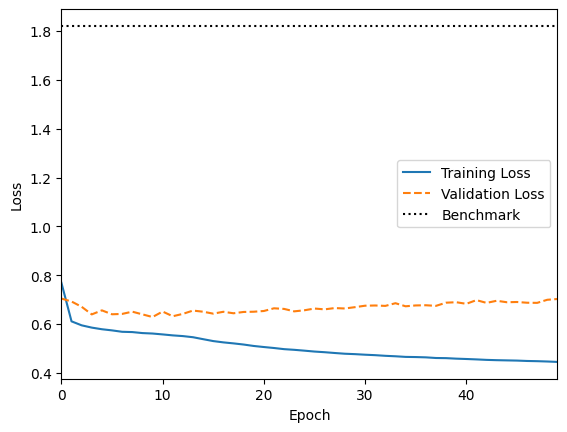

In [87]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training(epochs, train_losses, val_losses, benchmark):
    """Plot the training and validation losses."""
    plt.plot(range(epochs), train_losses, label="Training Loss")
    plt.plot(range(epochs), val_losses, "--", label="Validation Loss")
    plt.plot([0, epochs - 1], [benchmark, benchmark], ":k", label="Benchmark")
    plt.xlabel("Epoch")
    plt.xlim([0, epochs - 1])
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

ys = []
for _, y in DataLoader(ds_test, batch_size=128):
    ys.append(y)
ys = torch.cat(ys, dim=0).numpy()
if ys.ndim == 3:
    ys = ys[:, :, 0]

naive_errors = np.abs(ys[max(horizon):] - ys[:-max(horizon)])
naive_mae = naive_errors.mean()

print(f"Naive MAE: {naive_mae:.4f}")

train_losses = history['train_loss']
val_losses   = history['val_loss']
plot_training(50, train_losses, val_losses, benchmark = naive_mae)

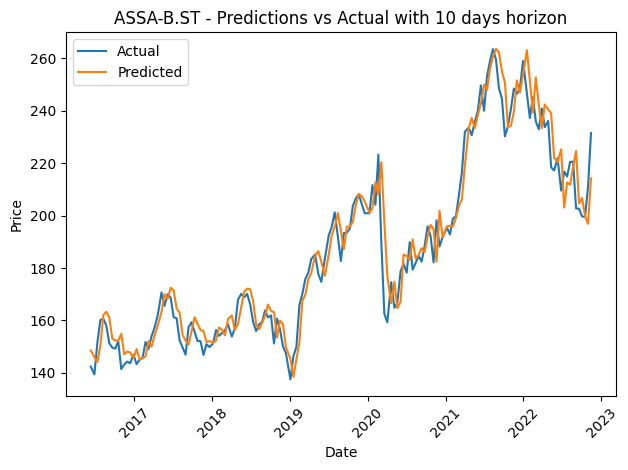

Accuracy: 0.0334
Total accuracy on last horizon: 0.0457
ASSA-B.ST: 0.0343
ATCO-A.ST: 0.0419
ATCO-B.ST: 0.0420
AZN.ST: 0.0380
ELUX-B.ST: 0.0550
ERIC-B.ST: 0.0500
GETI-B.ST: 0.0528
HEXA-B.ST: 0.0421
HM-B.ST: 0.0600
INVE-B.ST: 0.0321
KINV-B.ST: 0.0544
NDA-SE.ST: 0.0440
NIBE-B.ST: 0.0561
SAAB-B.ST: 0.0576
SAND.ST: 0.0439
SCA-B.ST: 0.0486
SEB-A.ST: 0.0397
SHB-A.ST: 0.0379
SKF-B.ST: 0.0504
SWED-A.ST: 0.0425
TEL2-B.ST: 0.0369
VOLV-B.ST: 0.0453
Stock accuracy: 0.0343


In [88]:
import importlib
import functions.plot_predictions
importlib.reload(functions.plot_predictions)
from functions.plot_predictions import plot_predictions

model.load_state_dict(torch.load(save_path))
model.eval()
idx = 0
plot_predictions(
    idx,
    tickers,
    val_loader.dataset,
    model,
    0,
    20000
)

# Test on val-set to adjust optimization

               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [0.99886527 1.00593267 0.99949774 0.98110644 0.98950271 0.98396028
 0.99662593 0.9867391  0.97752479 0.955102  ]
Weights: [0.0000000e+00 0.0000000e+00 0.0000000e+00 3.6617675e-01 5.9475502e-18
 3.0981538e-01 0.0000000e+00 0.0000000e+00 6.6066043e-18 0.0000000e+00
 0.0000000e+00 6.6456294e-18 1.7407033e-17 0.0000000e+00 0.0000000e+00
 0.0000000e+00 9.3417756e-19 0.0000000e+00 8.2685404e-18 2.2637831e-17
 0.0000000e+00 3.2400787e-01]
Full horizon predictions: tensor([148.5514,  33.6167,  29.6355, 471.5186, 138.1232,  53.3793, 109.3102,
         45.4117, 182.3240,  61.3328, 100.1975,  77.8649,  17.3830,  60.9296,
         69.1640,  44.5013,  55.4260,  72.6800, 112.9199, 102.6165,  41.8023,
         68.1688])
Last know prices: tensor([146.9625,  32.6382,  28.9454, 463.9162, 132.5318,  51.6390, 106.7377,
         44.5239, 178.1694

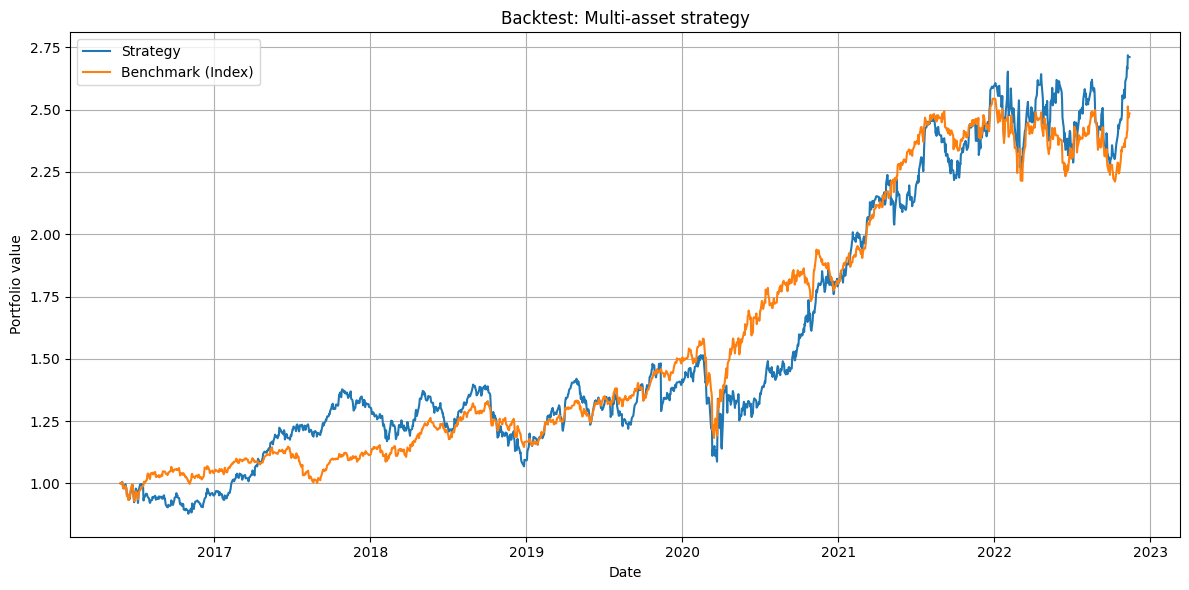

[[0.0, 0.0, 0.0, 0.3661767542362213, 5.947550199806314e-18, 0.309815376996994, 0.0, 0.0, 6.606604284906408e-18, 0.0, 0.0, 6.645629425435741e-18, 1.7407033300610754e-17, 0.0, 0.0, 0.0, 9.34177562160104e-19, 0.0, 8.268540416471917e-18, 2.2637830672459258e-17, 0.0, 0.32400786876678467], [2.30750674254707e-16, 1.4132357604411326e-17, 0.14747661352157593, 0.20536410808563232, 0.0, 9.873111986147181e-17, 0.18357211351394653, 9.292992851770879e-18, 0.14799150824546814, 2.593682647128448e-16, 0.0, 4.479135040499117e-17, 4.745971925580148e-17, 0.16363197565078735, 2.59911067248247e-17, 6.223227164093699e-19, 0.07964926958084106, 1.0590705064171223e-16, 0.0, 0.07231443375349045, 0.0, 7.17282885294335e-18], [0.0, 1.5835510905129435e-17, 6.6704357448255935e-18, 7.179051567255464e-17, 2.3189404631076967e-18, 0.0, 0.0, 1.814566753731243e-17, 0.0, 2.8466130379256865e-17, 2.5837830157318624e-17, 0.040704548358917236, 0.0, 0.0, 1.8823944059077338e-17, 1.924662508028581e-17, 0.09084071964025497, 3.87453

In [114]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_val.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=2.0
)

result = backtest_multi_asset(
    ds_val,
    model,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.00,
)
print(result["weights"])
print(f"Mean weights: {np.array(result['weights']).mean(axis=0)}")

               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [1.01734312 1.00526889 1.00139999 1.00260696 1.01835273 1.02419064
 1.01311968 1.0051818  1.01305845 1.00801104]
Weights: [0.0000000e+00 0.0000000e+00 0.0000000e+00 4.1292617e-01 0.0000000e+00
 1.4271228e-16 0.0000000e+00 1.0680638e-17 0.0000000e+00 3.4626505e-17
 4.9556309e-01 6.3388154e-02 0.0000000e+00 2.8122583e-02 0.0000000e+00
 0.0000000e+00 3.9442764e-17 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00]
Full horizon predictions: tensor([ 225.4999,  124.9135,  112.1195, 1530.6127,  134.8530,   57.4547,
         243.0683,  117.9490,  140.6168,  200.9359,  167.8775,  117.1631,
         122.1669,  160.5671,  208.5928,  129.7306,  104.8141,   84.5358,
         193.5241,  154.0926,   92.7801,  197.3342])
Last know prices: tensor([ 224.6278,  124.5393,  111.7046, 1514.2098,  135.1000,   57.4056,
        

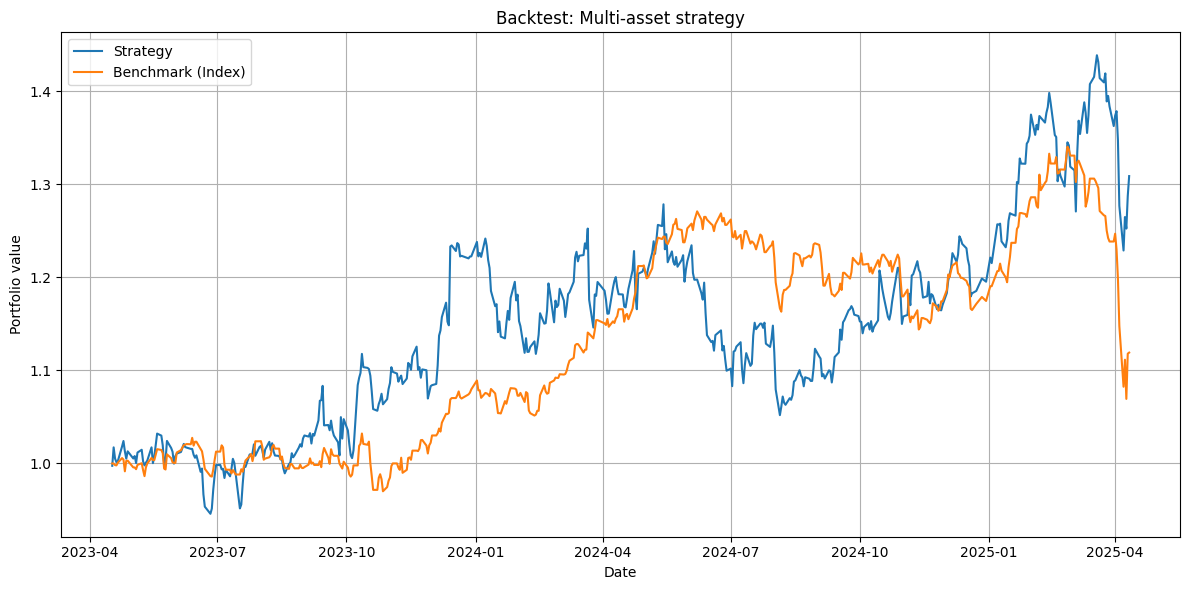

[[0.0, 0.0, 0.0, 0.41292616724967957, 0.0, 1.427122799436918e-16, 0.0, 1.0680637960165336e-17, 0.0, 3.4626505051686335e-17, 0.4955630898475647, 0.0633881539106369, 0.0, 0.028122583404183388, 0.0, 0.0, 3.944276416827634e-17, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 3.626244000146716e-17, 0.0, 1.290929033592389e-16, 0.0, 2.9469462081103265e-16, 0.0, 0.0, 0.0, 1.6327433561053495e-17, 0.0, 0.0, 0.11016537249088287, 8.909836174591416e-18, 0.0, 1.130602107940503e-16, 8.866558912123254e-18, 0.5220221281051636, 4.5976369350534635e-18, 0.0, 0.36781248450279236, 0.0], [1.3028359345506203e-16, 0.2525504529476166, 0.0, 4.0429673357113356e-17, 0.0, 0.32874351739883423, 7.783801989604002e-17, 5.515588708433365e-17, 5.1388423501289433e-17, 9.033497194626256e-17, 0.0, 0.0897703543305397, 0.3080342710018158, 0.0, 1.8306665008656077e-16, 0.020901383832097054, 0.0, 2.4102846946629475e-17, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 1.4143532814486918e-17, 0.0, 0.09120680391788483, 0.0, 0.0, 0.0, 2.305211746481154e-18, 0.0, 0

In [115]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_test.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=2.0
)

result_lstm = backtest_multi_asset(
    ds_test,
    model,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.005,
)
print(result_lstm["weights"])
print(f"Mean weights: {np.array(result_lstm['weights']).mean(axis=0)}")

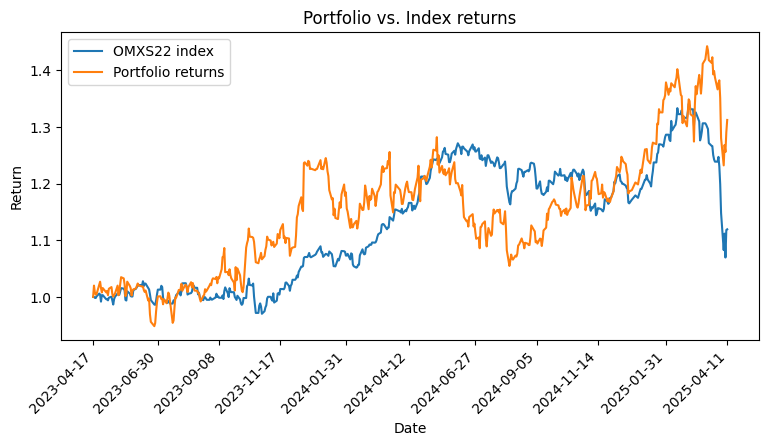

Last portfolio value: 1.3122
Last index value: 1.1192


In [118]:
portfolio_dates = result_lstm["dates"]
portfolio_vals = result_lstm["values"]
index_vals = result_lstm["benchmark"]


plt.figure(figsize=(9, 4))
if index_vals is not None:
    plt.plot(portfolio_dates[:], np.array(index_vals[:])/index_vals[0], label="OMXS22 index")
plt.plot(portfolio_dates[:], np.array(portfolio_vals[:])/portfolio_vals[0], label="Portfolio returns")
plt.xlabel("Date")
plt.xticks(
        portfolio_dates[::50], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.ylabel("Return")
plt.title("Portfolio vs. Index returns")
plt.legend()
plt.show()
print(f"Last portfolio value: {(np.array(portfolio_vals[:])/portfolio_vals[0])[-1]:.4f}")
print(f"Last index value: {(np.array(index_vals[:])/index_vals[0])[-1]:.4f}")

In [119]:
import torch.nn as nn

class CrossAttentionLSTMV1(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_hidden_layers, out_dim, dropout, num_heads):
        super().__init__()
        self.gru_model = nn.LSTM(in_dim, hidden_dim, num_layers=num_hidden_layers, dropout=dropout, batch_first=True)
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, kdim=hidden_dim, vdim=hidden_dim, dropout=0, batch_first=True)
        self.fuse_fc = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU()
        )
        self.fc = nn.Linear(hidden_dim, out_dim)
        self._stored_attn_weights = None

    def get_attn_weights(self):
        return self._stored_attn_weights

    def forward(self, x):
        gru_out, _ = self.gru_model(x)

        x_proj = self.input_proj(x)

        cross_attn_out, cross_attn_weights = self.cross_attn(query=gru_out, key=x_proj, value=x_proj)

        self._stored_attn_weights = cross_attn_weights.detach()
        #print('gru:', gru_out)
        #print('cross attn: ', cross_attn_out)

        combined = cross_attn_out+gru_out
        #fused = self.fuse_fc(combined)
        #print(combined.shape)

        final_step = combined[:, -1, :]
        #print(final_step.shape)

        output = self.fc(final_step)

        return output

In [121]:
import deeplay as dl
cross_attention_lstm_model = CrossAttentionLSTMV1(in_dim=len(tickers)*len(features), hidden_dim=144, num_hidden_layers=2, out_dim=len(tickers)*len(horizon), dropout=0.2, num_heads=24)

cross_attention_lstm_reg = dl.Regressor(cross_attention_lstm_model, optimizer=dl.Adam(lr=0.001)).create()

trainer_cross_lstm = dl.Trainer(max_epochs=30, accelerator="auto")
trainer_cross_lstm.fit(cross_attention_lstm_reg, train_loader, val_loader)

train_losses = trainer_cross_lstm.history.history["train_loss_epoch"]["value"]
val_losses = trainer_cross_lstm.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | train
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 424 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
424 K     Trainable params
0         Non-trainable params
424 K     Total params
1.697     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 188/188 [00:23<00:00,  8.10it/s, v_num=46, train_loss_step=0.410, val_loss_step=0.719, val_loss_epoch=0.686, train_loss_epoch=0.398]


               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [0.99884441 1.00310273 0.99048041 0.9787387  0.98535506 0.97431593
 0.98658522 0.98105736 0.96702206 0.94299469]
Weights: [3.58588453e-17 9.54098822e-18 0.00000000e+00 3.92938763e-01
 2.65104976e-02 1.07911505e-01 1.81964846e-17 0.00000000e+00
 7.26926252e-02 6.54605963e-18 0.00000000e+00 1.34521686e-17
 3.76409944e-18 1.80515707e-01 5.43792102e-19 9.82853026e-18
 3.62948850e-02 5.73810062e-18 1.75175115e-01 1.71813292e-18
 7.96089973e-03 0.00000000e+00]
Full horizon predictions: tensor([146.5106,  32.6706,  29.9926, 450.0504, 135.1214,  53.3496, 105.8013,
         42.9393, 179.4608,  60.1926,  98.0993,  75.7414,  16.9364,  59.6884,
         69.0810,  43.9257,  55.1562,  71.4278, 110.9285, 102.1658,  41.1858,
         66.6848])
Last know prices: tensor([146.9625,  32.6382,  28.9454, 463.9162, 132.5318,  51.6390, 106.7377,
   

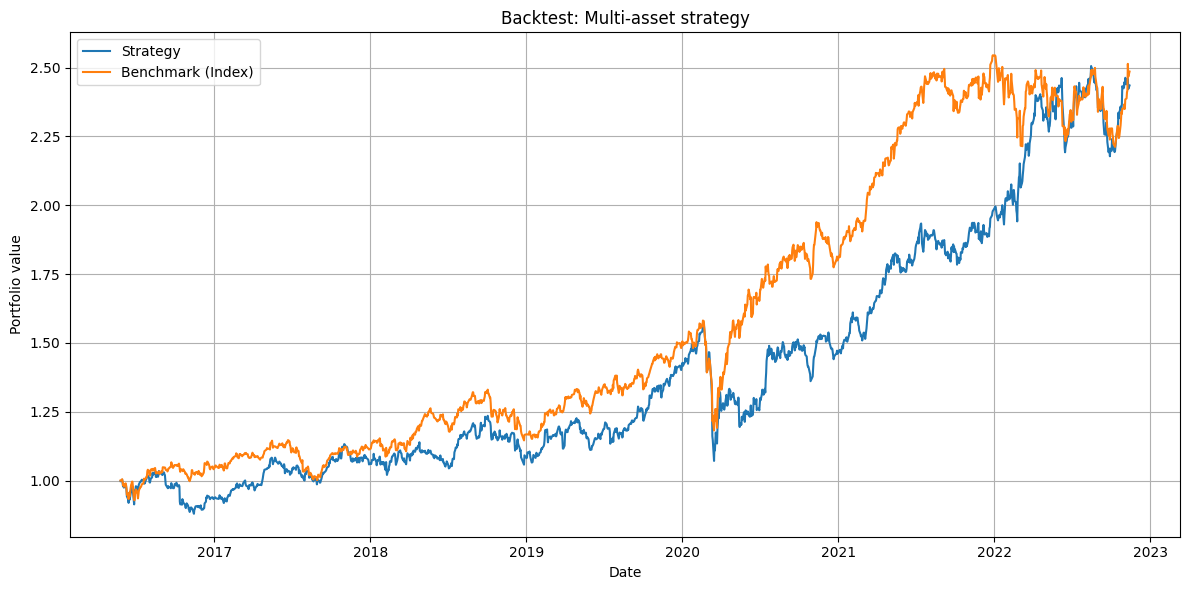

[[3.5858845345712736e-17, 9.540988216859177e-18, 0.0, 0.3929387629032135, 0.02651049755513668, 0.10791150480508804, 1.8196484551064013e-17, 0.0, 0.0726926252245903, 6.5460596271512014e-18, 0.0, 1.3452168641070197e-17, 3.764099439492966e-18, 0.18051570653915405, 5.43792101908752e-19, 9.828530259853023e-18, 0.036294884979724884, 5.738100624082375e-18, 0.17517511546611786, 1.7181329212259842e-18, 0.007960899733006954, 0.0], [0.0, 0.0, 0.0, 0.3382159173488617, 0.018033890053629875, 0.049207042902708054, 0.12508440017700195, 0.0, 0.0771365761756897, 0.0, 0.0, 7.020138756491574e-18, 0.0, 0.15873681008815765, 0.0, 8.765450971489673e-18, 0.0615561343729496, 1.6695767161656008e-17, 0.17202922701835632, 0.0, 3.0671648250361597e-18, 0.0], [0.0, 5.4457476986459205e-18, 0.0, 0.4499978721141815, 0.05898524448275566, 0.1133483275771141, 0.02381114475429058, 0.0, 9.697901897518649e-18, 0.0, 6.456128550954436e-18, 0.0, 2.1550766041464013e-18, 0.10396058112382889, 0.0, 1.4691956869332025e-17, 3.63252928

In [130]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_val.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=0.01
)

result = backtest_multi_asset(
    ds_val,
    cross_attention_lstm_reg,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.005,
)
print(result["weights"])
print(f"Mean weights: {np.array(result['weights']).mean(axis=0)}")

               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [1.0096423  1.00786599 1.0095523  1.01606993 1.01946299 1.01882196
 0.99903396 1.03955671 1.04074204 1.0292698 ]
Weights: [2.44393811e-01 8.89045781e-17 2.87349492e-01 3.48875314e-01
 0.00000000e+00 0.00000000e+00 9.10729825e-18 0.00000000e+00
 8.67361738e-19 0.00000000e+00 0.00000000e+00 0.00000000e+00
 4.44522891e-18 1.35867950e-02 1.21430643e-17 1.10588622e-17
 0.00000000e+00 1.05794586e-01 7.80625564e-18 4.55364912e-18
 5.69206141e-18 0.00000000e+00]
Full horizon predictions: tensor([ 225.5703,  124.5168,  111.3429, 1540.7858,  135.9748,   57.9176,
         249.0034,  116.5904,  142.9186,  200.6465,  166.9795,  118.8950,
         116.4242,  161.6299,  206.4522,  129.5858,  104.5952,   80.5254,
         187.2152,  157.4331,   94.7999,  199.5003])
Last know prices: tensor([ 224.6278,  124.5393,  111.7046, 1514.2098,  135.10

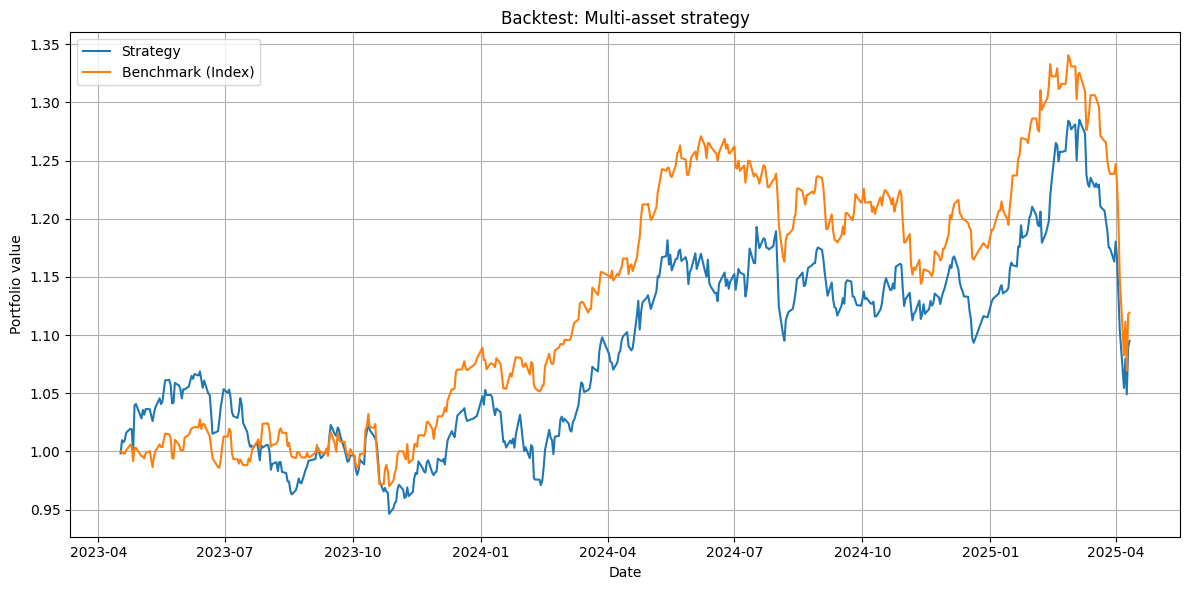

[[0.24439381062984467, 8.890457814381136e-17, 0.28734949231147766, 0.3488753139972687, 0.0, 0.0, 9.107298248878237e-18, 0.0, 8.673617379884035e-19, 0.0, 0.0, 0.0, 4.445228907190568e-18, 0.013586794957518578, 1.214306433183765e-17, 1.1058862159352145e-17, 0.0, 0.10579458624124527, 7.806255641895632e-18, 4.553649124439119e-18, 5.692061405548898e-18, 0.0], [0.26441189646720886, 4.9873299934333204e-18, 0.12407583743333817, 0.2759307324886322, 4.8626467435974874e-17, 0.1954788714647293, 1.0083080204115191e-17, 8.527927712956296e-18, 0.0, 2.8731357570865868e-18, 0.0, 1.2305694657710475e-17, 0.0, 0.023520857095718384, 0.0, 0.0, 9.252987915805977e-18, 0.11658179759979248, 0.0, 0.0, 7.643625316022806e-18, 1.8323016715005025e-17], [0.2920994162559509, 1.1167282376600696e-17, 0.057197291404008865, 0.27081403136253357, 0.0, 0.2592458128929138, 0.0, 3.155028321932818e-17, 5.204170427930421e-18, 5.204170427930421e-18, 0.0, 7.15573433840433e-18, 0.0, 0.02596071921288967, 7.589415207398531e-19, 2.6020

In [135]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_test.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=0.01
)

result_crossattn_lstm = backtest_multi_asset(
    ds_test,
    cross_attention_lstm_reg,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.005,
)
print(result_crossattn_lstm["weights"])
print(f"Mean weights: {np.array(result_crossattn_lstm['weights']).mean(axis=0)}")

<Figure size 900x400 with 0 Axes>

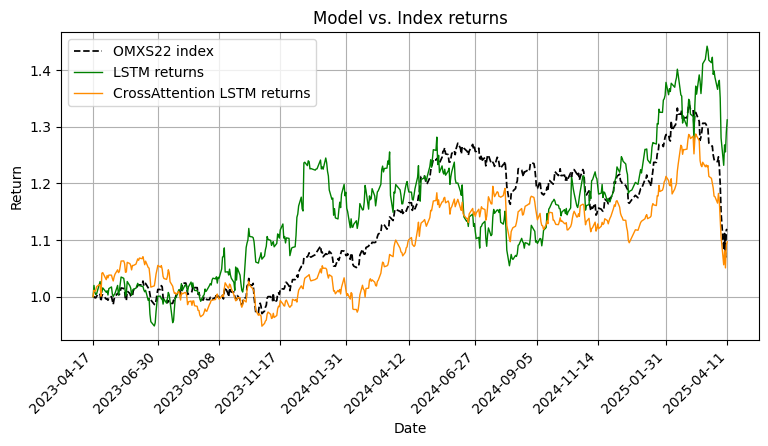

LSTM portfolio value: 1.3122
CrossAttention LSTM portfolio value: 1.0969
Index value: 1.1192
LSTM Sharpe Ratio: 1.1950
CrossAttention LSTM Sharpe Ratio: 0.8518
Index Sharpe Ratio: 1.0257
LSTM Max Drawdown: -0.1772
CrossAttention LSTM Max Drawdown: -0.1837
Index Max Drawdown: -0.2022


In [171]:
portfolio_dates = result_crossattn_lstm["dates"]
crossattn_lstm_portfolio_vals = result_crossattn_lstm["values"]
index_vals = result_crossattn_lstm["benchmark"]
lstm_portfolio_vals = result_lstm["values"]
plt.figure(figsize=(9, 4))

plt.figure(figsize=(9, 4))
if index_vals is not None:
    plt.plot(portfolio_dates[:], np.array(index_vals[:])/index_vals[0], label="OMXS22 index", color="black", linewidth=1.25, linestyle="--")
plt.plot(portfolio_dates[:], np.array(lstm_portfolio_vals[:])/lstm_portfolio_vals[0], label="LSTM returns", color="green", linewidth=1.0)
plt.plot(portfolio_dates[:], np.array(crossattn_lstm_portfolio_vals[:])/crossattn_lstm_portfolio_vals[0], label="CrossAttention LSTM returns", color="darkorange", linewidth=1.0)
plt.xlabel("Date")
plt.xticks(
        portfolio_dates[::50], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.ylabel("Return")
plt.title("Model vs. Index returns")
plt.grid()
plt.legend()
plt.show()
print(f"LSTM portfolio value: {(np.array(lstm_portfolio_vals[:])/lstm_portfolio_vals[0])[-1]:.4f}")
print(f"CrossAttention LSTM portfolio value: {(np.array(crossattn_lstm_portfolio_vals[:])/crossattn_lstm_portfolio_vals[0])[-1]:.4f}")
print(f"Index value: {(np.array(index_vals[:])/index_vals[0])[-1]:.4f}")

def sharpe_ratio(returns, risk_free_rate=0.02):
    """
    Calculate the Sharpe ratio of a series of returns.
    """
    excess_returns = returns - risk_free_rate
    return np.mean(excess_returns) / np.std(excess_returns)

def max_drawdown(returns):
    """
    Calculate the maximum drawdown of a series of returns.
    """
    peak = np.maximum.accumulate(returns)
    drawdown = (returns - peak) / (1 + peak)
    return np.min(drawdown)

# Calculate the performance metrics
lstm_returns = np.array(lstm_portfolio_vals[:])/lstm_portfolio_vals[0] - 1
crossattn_lstm_returns = np.array(crossattn_lstm_portfolio_vals[:])/crossattn_lstm_portfolio_vals[0] - 1
index_returns = np.array(index_vals[:])/index_vals[0] - 1
lstm_sharpe = sharpe_ratio(lstm_returns)
crossattn_lstm_sharpe = sharpe_ratio(crossattn_lstm_returns)
index_sharpe = sharpe_ratio(index_returns)
lstm_max_drawdown = max_drawdown(lstm_returns)
crossattn_lstm_max_drawdown = max_drawdown(crossattn_lstm_returns)
index_max_drawdown = max_drawdown(index_returns)
print(f"LSTM Sharpe Ratio: {lstm_sharpe:.4f}")
print(f"CrossAttention LSTM Sharpe Ratio: {crossattn_lstm_sharpe:.4f}")
print(f"Index Sharpe Ratio: {index_sharpe:.4f}")
print(f"LSTM Max Drawdown: {lstm_max_drawdown:.4f}")
print(f"CrossAttention LSTM Max Drawdown: {crossattn_lstm_max_drawdown:.4f}")
print(f"Index Max Drawdown: {index_max_drawdown:.4f}")
    

In [162]:
print(crossattn_lstm_portfolio_vals[0])

0.9982556234300136
